In [1]:
# Install and imports (run first)
import sympy as sp
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

s = sp.symbols('s')
Y, X = sp.symbols('Y X')

print("Ready! Run Cell 2.")

Ready! Run Cell 2.


In [2]:
# Input and calculation
eq_input = input("Equation (2*D**2*y+D*y=D*x+x): ").replace(' ', '')

# Parse to Laplace domain
eq_parsed = (eq_input.replace('D**2*y', 's**2*Y').replace('D*y', 's*Y')
              .replace('D**2*x', 's**2*X').replace('D*x', 's*X')
              .replace('D**2*u', 's**2*X').replace('D*u', 's*X')
              .replace('y""', 's**2*Y').replace("y'", 's*Y')
              .replace('y', 'Y').replace('x', 'X').replace('u', 'X'))

print(f"Parsed: {eq_parsed}")

# Left = Right → Right - Left = 0
lhs_str, rhs_str = eq_parsed.split('=')
lhs = sp.sympify(lhs_str)
rhs = sp.sympify(rhs_str)

eqn = rhs - lhs
denom = -eqn.coeff(Y)  # Positive denominator
num = eqn.coeff(X)

tf_expr = num / denom
print(f"\nT(s) = {tf_expr}")

# System
num_coeffs = [float(c) for c in sp.Poly(num, s).all_coeffs()]
den_coeffs = [float(c) for c in sp.Poly(denom, s).all_coeffs()]
sys = ctrl.tf(num_coeffs, den_coeffs)

print(f"Num: {num_coeffs}")
print(f"Den: {den_coeffs}")
print(sys)
print(f"Poles: {ctrl.poles(sys)}")
print(f"Zeros: {ctrl.zeros(sys)}")

Parsed: 2*s**2*Y+s*Y=s*X+X

T(s) = (s + 1)/(2*s**2 + s)
Num: [1.0, 1.0]
Den: [2.0, 1.0, 0.0]
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s
Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


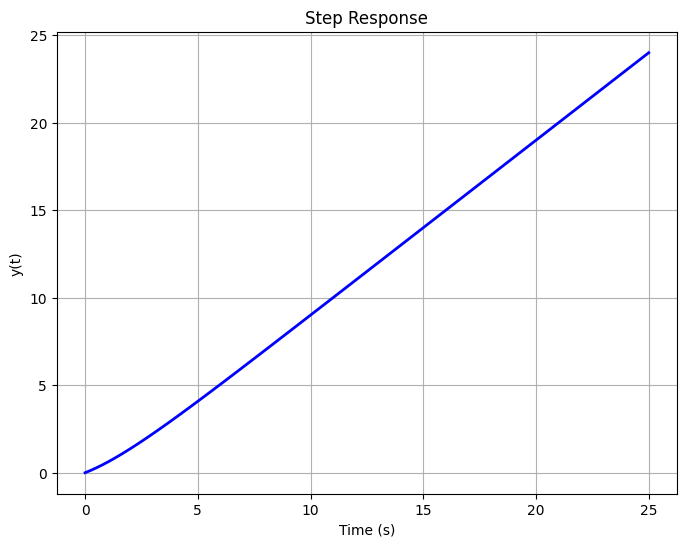

In [3]:
# STEP RESPONSE (separate plot)
t, y = ctrl.step_response(sys)
plt.figure(figsize=(8, 6))
plt.plot(t, y, 'b-', linewidth=2)
plt.title('Step Response')
plt.xlabel('Time (s)')
plt.ylabel('y(t)')
plt.grid(True)
plt.show()

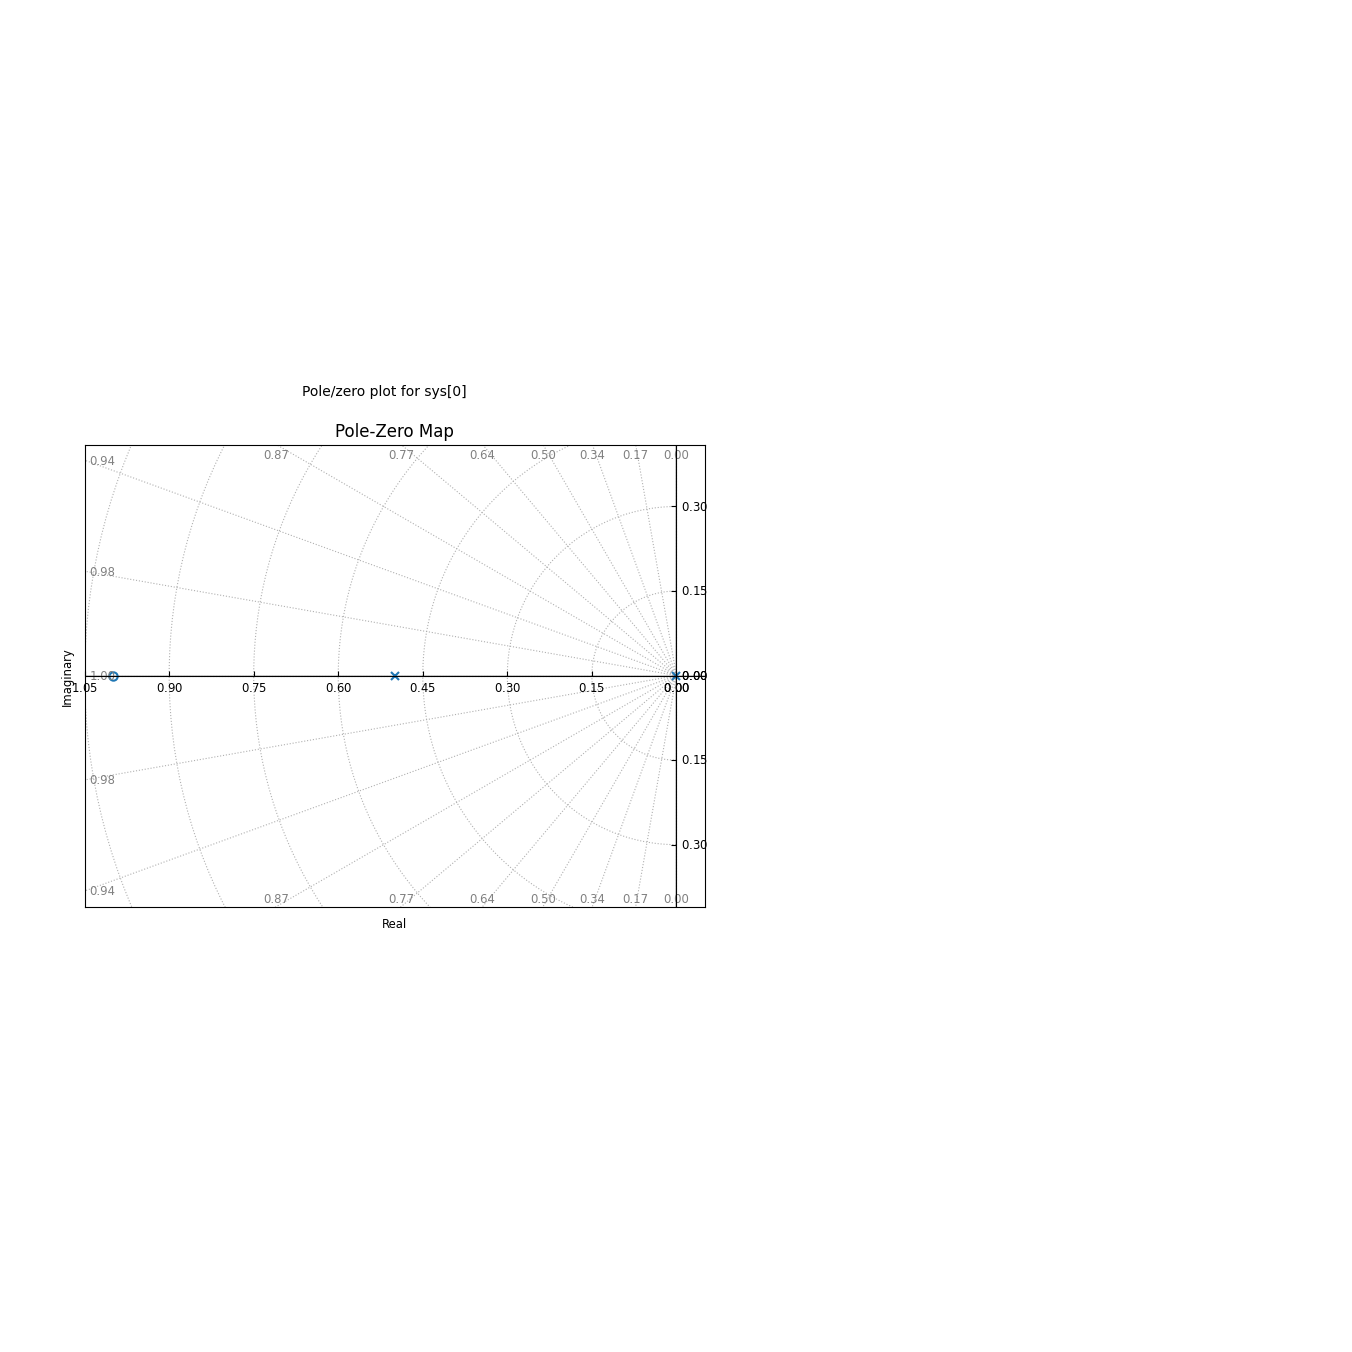

In [4]:
# CELL 4: POLE-ZERO MAP (separate plot)  
plt.figure(figsize=(8, 6))
ctrl.pzmap(sys, grid=True)
plt.title('Pole-Zero Map')
plt.show()